In [64]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as si
import scipy.optimize as so
import scipy.fft as sf

In [65]:
def Sist_solar_mod(t,x_v):
    # x_v = ( x,y,vx,vy )
    dx = x_v[2]
    dy = x_v[3]
    r32 = (x_v[0]**2 + x_v[1]**2 )**1.5
    dvx , dvy = -x_v[0]/r32 , -x_v[1]/r32
    return np.array([dx,dy,dvx,dvy])

In [66]:
ci = [ 1 , 0 , 0 , 1 ]
t = (0,40*np.pi)
x_v = si.solve_ivp(Sist_solar_mod,t,ci,rtol=1e-6,atol=1e-10)
print(x_v.success)

True


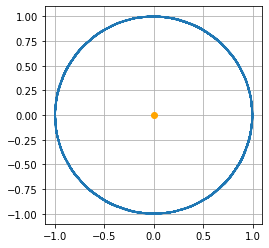

In [67]:
plt.plot(x_v.y[0],x_v.y[1])
plt.gca().set_aspect('equal')
plt.plot([0],[0],'o',color='orange')
plt.grid()
plt.show()

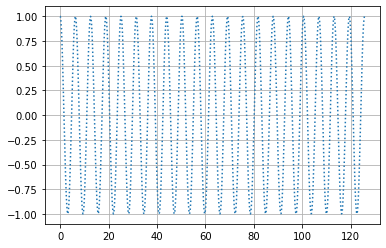

In [68]:
plt.plot(x_v.t,x_v.y[0],':')
plt.grid()
plt.show()

In [106]:
ci = [ 1 , 0 , 0 , 1 ]
t = (0,200*2*np.pi)
x_v_cont = si.solve_ivp(Sist_solar_mod,t,ci,rtol=1e-8,atol=1e-10,
                        dense_output=True)
print(x_v_cont.success)

True


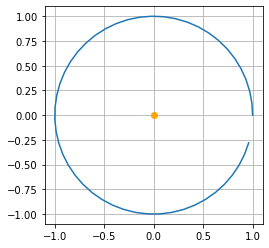

In [107]:
x_v_interpolado = x_v_cont.sol(np.linspace(0,6) )
plt.plot(x_v_interpolado[0],x_v_interpolado[1])
plt.gca().set_aspect('equal')
plt.plot([0],[0],'o',color='orange')
plt.grid()
plt.show()

In [108]:
def sol_y(t):
    return x_v_cont.sol(t)[1]

In [109]:
so.newton(sol_y,6.2)

6.283185285289168

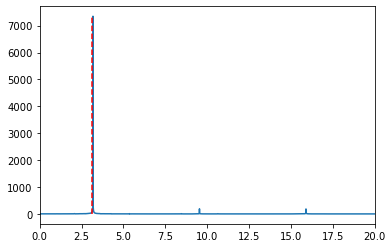

In [110]:
d_T , N = x_v_cont.t[1]-x_v_cont.t[0] , len(x_v_cont.t)
T_x = sf.fft(x_v_cont.y[0])[:N//2]
T_t = abs(sf.fftfreq(N,d_T))[:N//2]
plt.plot(T_t,abs(T_x))
plt.vlines([np.pi],0,max(abs(T_x)),ls='dashed',color='red')
plt.xlim([0,20])
plt.show()